# 04. Supervised Soft-Sensor: Industrial Baselines & Stratified Validation

In the previous notebooks, we constructed a physics-informed feature space (Notebook 02) and discovered the latent thermodynamic operating regimes of the motor (Notebook 03). 

This notebook represents the core predictive modeling phase. Our objective is to train and validate deterministic, non-Deep-Learning regression models to estimate the unobservable `stator_winding` temperature using only deployment-ready telemetry.

## Objectives
1. **Industrial Baselines:** Establish robust performance metrics using computationally efficient algorithms (Penalized Linear Regression and Histogram-based Gradient Boosting) suitable for Electronic Control Unit (ECU) deployment.
2. **Strict Causal Validation:** Implement a rigorous Group-Aware cross-validation strategy to definitively prevent temporal data leakage.
3. **Stratified Error Analysis:** Evaluate model robustness not just globally, but on a per-profile and per-regime basis, ensuring the Soft-Sensor performs safely across all physical states (Traction, Braking, Cruising).

---

## 1. Strict MLOps Constraints & Causal Validation Protocol

Before importing models, we must define the absolute boundaries of our validation framework. Time-series telemetry sampled at $2\text{ Hz}$ exhibits massive temporal autocorrelation. A standard randomized split would allow the model to memorize adjacent timestamps, yielding catastrophic overfitting and a false sense of accuracy.

> **The Group-Isolation Mandate**
> * **Zero Row-Level Splitting:** All `train/test` splits and Cross-Validation folds are strictly isolated by `profile_id`. A driving session used for validation must be completely unseen during the training phase. 
> * **Dynamic Regime Re-computation:** To evaluate errors by operating regime (Traction, Cruising, etc.), the K-Means pipeline from Notebook 03 cannot be applied globally upfront. It must be dynamically `.fit()` **only on the active training fold** and `.transform()` onto the validation fold. This prevents the unsupervised algorithm from inadvertently leaking future geometrical structure into the current validation state.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans

from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
rng = np.random.RandomState(SEED)

DATA = Path("../data/parquet")
TARGET = "stator_winding"
GROUP = "profile_id"

---

## 2. Evaluation Framework & Defensive MLOps Utilities

To guarantee the reproducibility and safety of our models, we first define a strict, defensive evaluation framework. 

### 2.1 Group-Aware Error Tracking
In industrial deployment, a global Mean Absolute Error (MAE) is mathematically insufficient and potentially dangerous. A model might achieve an excellent global MAE by overfitting to standard driving conditions while failing catastrophically on a rare, high-stress cycle. 

Therefore, our primary metric of robustness is the **Per-Profile MAE**. By computing errors explicitly grouped by `profile_id`, we can inspect the worst-case scenarios and ensure the Soft-Sensor is universally reliable across all boundary conditions. All metrics are guarded by strict finite-state assertions (`np.isfinite`) to prevent silent numerical propagation errors during validation.

In [38]:
# ----------------------------
# Metrics (global + per-profile)
# ----------------------------

def eval_metrics(y_true, y_pred):
    """Return global regression metrics with strict sanity checks."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    assert y_true.shape == y_pred.shape, "y_true and y_pred shapes mismatch"
    assert np.isfinite(y_true).all(), "Non-finite values in y_true"
    assert np.isfinite(y_pred).all(), "Non-finite values in y_pred"

    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }

def per_group_metrics(df_eval, group_col=GROUP):
    """
    Compute MAE/RMSE per group (e.g., profile_id).
    df_eval must contain: [group_col, y_true, y_pred]
    """
    required = {group_col, "y_true", "y_pred"}
    missing = required - set(df_eval.columns)
    assert not missing, f"df_eval missing columns: {missing}"

    # Finite checks
    assert np.isfinite(df_eval["y_true"].to_numpy()).all(), "Non-finite values in y_true"
    assert np.isfinite(df_eval["y_pred"].to_numpy()).all(), "Non-finite values in y_pred"

    g = df_eval.groupby(group_col, observed=True)

    out = pd.DataFrame({
        "MAE": g.apply(lambda d: mean_absolute_error(d["y_true"], d["y_pred"])),
        "RMSE": g.apply(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"]))),
        "N": g.size(),
    }).sort_values("MAE", ascending=False)

    return out

### 2.2 The Label Permutation Problem & Bipartite Matching

To perform our Stratified Error Analysis across cross-validation folds, we must project the active validation data into our thermodynamic regimes. However, this introduces two major mathematical challenges:

1. **Strict Causal Pipeline:** The entire non-linear space reduction (RobustScaler $\rightarrow$ PCA $\rightarrow$ K-Means) must be re-fitted exclusively on the active training fold.
2. **Stochastic Label Invariance:** K-Means optimization is invariant to label permutations. The centroid representing "Active Traction" might be assigned label $k=0$ in Fold 1, but label $k=3$ in Fold 2. 

To safely aggregate regime-specific errors across multiple folds, we must mathematically align the fold-specific latent centroids with a fixed global reference. We formulate this as a **Minimum Weight Bipartite Matching Problem**. 

We compute the distance matrix $C$ between the active fold centroids $\mu^{(fold)}$ and the reference centroids $\mu^{(ref)}$, where $C_{i,j} = ||\mu_i^{(fold)} - \mu_j^{(ref)}||_2$. We then deploy the **Hungarian Algorithm** (`scipy.optimize.linear_sum_assignment`) to find the optimal bijective mapping in $O(K^3)$ time, ensuring that physical regimes are perfectly synchronized before error aggregation.

In [39]:
# ----------------------------
# Train-only regime discovery (optional diagnostic)
# ----------------------------

def fit_regimes_on_train(X_train_df, n_pca=20, k=4, seed=SEED):
    """
    Fit RobustScaler -> PCA -> MiniBatchKMeans on TRAIN ONLY (anti-leakage).
    Returns fitted (scaler, pca, kmeans).
    """
    scaler = RobustScaler()
    Xtr_s = scaler.fit_transform(X_train_df)  # float64 typically, ok for stability

    pca = PCA(n_components=n_pca, random_state=seed)
    Xtr_p = pca.fit_transform(Xtr_s)

    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=8192,
        n_init=10,
        max_iter=500,
    )
    km.fit(Xtr_p)

    return scaler, pca, km

def predict_regimes(scaler, pca, km, X_df):
    """Predict regime IDs for X_df using fitted train-only (scaler, pca, km)."""
    Xs = scaler.transform(X_df)
    Xp = pca.transform(Xs)
    assert np.isfinite(Xp).all(), "Non-finite values after PCA transform"
    return km.predict(Xp)


# ----------------------------
# Optional: align regime IDs across folds (Hungarian matching)
# ----------------------------

try:
    from scipy.optimize import linear_sum_assignment
    from scipy.spatial.distance import cdist
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

def align_kmeans_centers(ref_centers, centers):
    """
    Align cluster IDs of `centers` to `ref_centers` using Hungarian assignment.
    Returns mapping old_label -> aligned_label.

    Requires SciPy. If SciPy is not available, raises RuntimeError.
    """
    if not _HAS_SCIPY:
        raise RuntimeError("SciPy is required for align_kmeans_centers (linear_sum_assignment, cdist).")

    ref_centers = np.asarray(ref_centers)
    centers = np.asarray(centers)

    assert ref_centers.ndim == 2 and centers.ndim == 2
    assert ref_centers.shape[1] == centers.shape[1], "Center dims mismatch"
    assert ref_centers.shape[0] == centers.shape[0], "K mismatch between ref and fold"

    dist_matrix = cdist(centers, ref_centers, metric="euclidean")
    row_ind, col_ind = linear_sum_assignment(dist_matrix)
    mapping = {int(old): int(new) for old, new in zip(row_ind, col_ind)}
    return mapping, dist_matrix

def apply_label_mapping(labels, mapping):
    """Vectorized remap of integer labels using mapping dict."""
    labels = np.asarray(labels, dtype=int)
    out = np.empty_like(labels)
    for old, new in mapping.items():
        out[labels == old] = new
    return out

---

## 3. Deterministic Baseline Architectures

To establish a highly reproducible engineering baseline, we bypass computationally opaque Deep Learning architectures in favor of two distinct, deployable paradigms: a regularized linear model and a non-linear gradient-boosted tree ensemble. 

No hyperparameter sweeping (e.g., GridSearchCV) is performed at this stage. Our objective is to evaluate the structural predictive power of our feature engineering under strict MLOps isolation.

### 3.1 Regularized Linear Baseline: Ridge Regression ($L_2$)
Our temporal feature engineering (overlapping rolling statistics) introduces massive multicollinearity into the design matrix $X$. A standard Ordinary Least Squares (OLS) regression would suffer from extreme variance in its coefficients. 
By employing **Ridge Regression** (applying an $L_2$ penalty to the $\beta$ vector), we mathematically stabilize the matrix inversion while retaining $O(1)$ inference time—a critical requirement for low-latency ECU deployment.
> **MLOps Pipeline Protocol:** The `StandardScaler` is strictly encapsulated within a Scikit-Learn `Pipeline` to ensure scaling statistics ($\mu, \sigma$) are computed exclusively on the active training folds, effectively neutralizing any topological data leakage.

### 3.2 Non-Linear Baseline: Histogram-Based Gradient Boosting
To capture the non-linear thermodynamic interactions (e.g., the complex cross-effects between high speed and thermal inertia), we deploy `HistGradientBoostingRegressor`. 
[Image of histogram-based gradient boosting algorithm]

**Architectural choices:**
* **Objective Function:** We explicitly override the default quadratic loss by forcing `loss="absolute_error"`. Industrial telemetry is heavy-tailed and prone to transient spikes. Optimizing for MAE forces the ensemble to fit the conditional median rather than the mean, rendering the model highly robust to sensor outliers.
* **Scalability:** The histogram-based binning achieves an asymptotic time complexity of $O(n \cdot \log(n))$ instead of the standard $O(n^2 \cdot \log(n))$, allowing rapid iterations across our 1.3-million-row dataset without memory exhaustion.
* **Regularization:** The ensemble is constrained via `max_depth=6` and `min_samples_leaf=20` to strictly prevent the memorization of high-frequency noise.

In [3]:
models = {
    "Ridge": Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", Ridge(alpha=1.0))
    ]),

    "HistGB": HistGradientBoostingRegressor(
        loss="absolute_error",
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        min_samples_leaf=20,
        l2_regularization=0.0,
        random_state=SEED,
    ),
}

---

## 4. Experimental Control: Shared Holdout Masking

The overarching goal of this project is to quantify the predictive degradation incurred when transitioning from a standard Soft-Sensor (`XB_soft`) to a strictly observable, degraded Soft-Sensor (`XB_strict`). 

To measure this delta accurately, we must adhere to the scientific principle of **ceteris paribus** (all other things being equal). If we allow our cross-validation generator to re-sample the train/test split for each dataset independently, any observed difference in the Mean Absolute Error (MAE) could be confounded by **split-induced variance** (e.g., inadvertently allocating mathematically harder driving profiles to the `XB_strict` test set).

[Image of paired sample testing isolating independent variables to control confounding factors]

### 4.1 Deterministic Index Locking
To isolate the independent variable (the engineered feature suite), we generate a single, immutable **Group-Aware Holdout Mask** ($80\%$ Train / $20\%$ Test) based on the `XB_soft` index. 
By saving the exact row indices (`shared_train_idx`, `shared_test_idx`), we force all subsequent models to be evaluated on the exact same chronological timestamps and the exact same $14$ driving sessions, regardless of the underlying feature matrix. 

> **MLOps Strict Constraint:** Reusing spatial indices across disparate DataFrames assumes absolute row-alignment (identical length and chronologic sorting). We will enforce this via programmatic assertions before executing the `XB_strict` pipeline.

In [6]:
df_soft = pd.read_parquet(DATA / "XB_soft.parquet")

assert TARGET in df_soft.columns and GROUP in df_soft.columns, "XB_soft missing TARGET/GROUP"
groups_soft = df_soft[GROUP].astype("category")

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
shared_train_idx, shared_test_idx = next(gss.split(df_soft, df_soft[TARGET], groups_soft))

# Safety checks
assert len(shared_train_idx) + len(shared_test_idx) == len(df_soft)
assert set(shared_train_idx).isdisjoint(set(shared_test_idx))

print("Shared holdout (defined on XB_soft):")
print("Train:", len(shared_train_idx))
print("Test :", len(shared_test_idx))
print("Test profiles:", groups_soft.iloc[shared_test_idx].nunique())

Shared holdout (defined on XB_soft):
Train: 1014323
Test : 301313
Test profiles: 14


---

## 5. The Core MLOps Engine: Automated Experiment Runner

To ensure strict comparability between the standard (`XB_soft`) and degraded (`XB_strict`) datasets, we abstract the entire training and evaluation pipeline into a single, deterministic orchestrator function: `run_experiment()`.

This function is designed to enforce rigorous engineering standards:
1. **Sanity Validations:** It actively scans the design matrix ($X$) for non-finite values (NaNs, Infs) before any computation, halting execution if structural data corruption is detected.
2. **The Naive Baseline:** It computes a zero-intelligence `NaiveMean` predictor. A Machine Learning model is only valid if its R² significantly outperforms this flat baseline.
3. **Dual-Phase Validation Protocol:**
    * **Phase A (Holdout):** Evaluates all candidates (Ridge, HistGBM) on the exact same chronological index slice.
    * **Phase B (GroupKFold):** Subjects the top-performing non-linear model (HistGBM) to a full 5-fold cross-validation (isolated by `profile_id`) to compute the true mathematical variance of the MAE.
4. **Automated Stratified Profiling:** For both phases, the function dynamically re-computes the thermodynamic regimes (RobustScaler $\rightarrow$ PCA $\rightarrow$ K-Means) strictly on the active training bounds. It then executes the Bipartite Matching (Hungarian algorithm) to align the labels and computes MAE/RMSE per physical regime.

This function guarantees that our evaluation is completely impervious to temporal leakage and observer bias.

In [8]:
def run_experiment(
    dataset_name,
    do_regimes=True,
    regimes_n_pca=20,
    regimes_k=4,
    n_splits=5,
    shared_split=None,
    shared_soft_profile_ids=None,  # optional: safety check for shared split alignment
):
    print("=" * 80)
    print("DATASET:", dataset_name)

    # -------------------
    # Load
    # -------------------
    df = pd.read_parquet(DATA / dataset_name)
    assert TARGET in df.columns and GROUP in df.columns, "Missing TARGET or GROUP."
    df[GROUP] = df[GROUP].astype("category")

    feature_cols = [c for c in df.columns if c not in [GROUP, TARGET]]
    assert len(feature_cols) > 0, "No feature columns found."

    X = df[feature_cols]
    y = df[TARGET]
    groups = df[GROUP]

    print(f"X: {X.shape} | y: {y.shape} | n_profiles: {groups.nunique()}")

    # Hard checks
    assert X.isna().sum().sum() == 0, "Unexpected NaNs in X"
    assert y.isna().sum() == 0, "Unexpected NaNs in y"
    assert np.isinf(X.select_dtypes(np.number)).sum().sum() == 0, "Unexpected inf in X"
    assert X.select_dtypes(exclude=[np.number]).shape[1] == 0, "Non-numeric columns in X"

    # -------------------
    # A) Holdout
    # -------------------
    if shared_split is None:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
    else:
        train_idx, test_idx = shared_split
        train_idx = np.asarray(train_idx)
        test_idx = np.asarray(test_idx)

        assert train_idx.max() < len(df) and test_idx.max() < len(df), "shared_split indices out of bounds"
        assert len(train_idx) + len(test_idx) == len(df), "shared_split must partition dataset rows"
        assert set(train_idx).isdisjoint(set(test_idx)), "shared_split train/test overlap"

        # Strong alignment check (recommended when comparing XB_soft vs XB_strict)
        if shared_soft_profile_ids is not None:
            # shared_soft_profile_ids should be df_soft[GROUP].values (aligned with shared_split indices)
            prof_here = df[GROUP].astype(str).values
            prof_soft = np.asarray(shared_soft_profile_ids).astype(str)
            assert len(prof_here) == len(prof_soft), "shared_soft_profile_ids length mismatch"
            assert np.all(prof_here[test_idx] == prof_soft[test_idx]), (
                "Shared split invalid: XB_strict rows do not match XB_soft rows at test indices. "
                "Datasets are likely not row-aligned."
            )

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

    print(f"Holdout Train: {X_train.shape} | Test: {X_test.shape}")
    print("Holdout profiles test:", g_test.nunique())

    # Naive baseline
    y_pred_naive = np.full(shape=len(y_test), fill_value=float(y_train.mean()))
    m_naive = eval_metrics(y_test, y_pred_naive)

    holdout_rows = [{
        "dataset": dataset_name,
        "model": "NaiveMean",
        **m_naive,
        "train_time_s": 0.0
    }]

    pred_store = {}
    for name, model in models.items():
        est = clone(model)
        t0 = time.time()
        est.fit(X_train, y_train)
        dt = time.time() - t0

        y_pred = est.predict(X_test)
        assert np.isfinite(y_pred).all(), f"Non-finite predictions for model {name}"

        pred_store[name] = y_pred
        m = eval_metrics(y_test, y_pred)

        holdout_rows.append({
            "dataset": dataset_name,
            "model": name,
            **m,
            "train_time_s": dt
        })
        print(f"{name:6s} | MAE={m['MAE']:.3f} RMSE={m['RMSE']:.3f} R2={m['R2']:.3f} | time={dt:.1f}s")

    holdout_df = pd.DataFrame(holdout_rows).sort_values("MAE").reset_index(drop=True)

    # pick best among real models only (exclude NaiveMean)
    candidates = holdout_df[holdout_df["model"] != "NaiveMean"].copy()
    assert len(candidates) > 0, "No candidate models."
    best_model = candidates.sort_values("MAE").iloc[0]["model"]
    best_pred = pred_store[best_model]

    # Holdout eval tables
    df_eval_holdout = pd.DataFrame({
        GROUP: g_test.values,
        "y_true": y_test.values,
        "y_pred": best_pred,
    })
    by_profile_holdout = per_group_metrics(df_eval_holdout, group_col=GROUP)

    # Holdout per-regime (train-only, reference space)
    by_regime_holdout = None
    ref_centers = None
    if do_regimes:
        scaler_ref, pca_ref, km_ref = fit_regimes_on_train(
            X_train, n_pca=regimes_n_pca, k=regimes_k, seed=SEED
        )
        ref_centers = km_ref.cluster_centers_
        reg_test = predict_regimes(scaler_ref, pca_ref, km_ref, X_test)

        df_eval_reg = df_eval_holdout.copy()
        df_eval_reg["regime_aligned"] = reg_test

        by_regime_holdout = (
            df_eval_reg.groupby("regime_aligned", observed=True)
            .apply(lambda d: pd.Series({
                "MAE": mean_absolute_error(d["y_true"], d["y_pred"]),
                "RMSE": np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])),
                "N": len(d),
            }))
            .sort_index()
        )

    # -------------------
    # B) CV (GroupKFold) — HistGB only
    # -------------------
    gkf = GroupKFold(n_splits=n_splits)
    cv_rows, prof_rows, reg_rows = [], [], []

    # ensure CV model matches the model family used above
    base_cv_model = clone(models["HistGB"])

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        g_te = groups.iloc[te]

        model_fold = clone(base_cv_model)
        t0 = time.time()
        model_fold.fit(X_tr, y_tr)
        dt = time.time() - t0

        y_hat = model_fold.predict(X_te)
        assert np.isfinite(y_hat).all(), f"Non-finite predictions in fold {fold}"

        m = eval_metrics(y_te, y_hat)
        cv_rows.append({
            "dataset": dataset_name,
            "fold": fold,
            **m,
            "train_time_s": dt,
            "n_test": len(te),
            "n_test_profiles": int(g_te.nunique())
        })
        print(f"[{dataset_name}] Fold {fold} | MAE={m['MAE']:.3f} RMSE={m['RMSE']:.3f} R2={m['R2']:.3f}")

        df_eval_fold = pd.DataFrame({
            GROUP: g_te.values,
            "y_true": y_te.values,
            "y_pred": y_hat,
        })

        by_prof = per_group_metrics(df_eval_fold, group_col=GROUP).reset_index()
        by_prof["fold"] = fold
        by_prof["dataset"] = dataset_name
        prof_rows.append(by_prof)

        if do_regimes:
            assert ref_centers is not None, "ref_centers must exist when do_regimes=True"

            scaler_r, pca_r, km_r = fit_regimes_on_train(
                X_tr, n_pca=regimes_n_pca, k=regimes_k, seed=SEED
            )

            reg_te_raw = predict_regimes(scaler_r, pca_r, km_r, X_te)
            mapping, _ = align_kmeans_centers(ref_centers, km_r.cluster_centers_)
            reg_te_aligned = apply_label_mapping(reg_te_raw, mapping)

            df_eval_reg = df_eval_fold.copy()
            df_eval_reg["regime_km_raw"] = reg_te_raw
            df_eval_reg["regime_aligned"] = reg_te_aligned

            by_reg = (
                df_eval_reg.groupby("regime_aligned", observed=True)
                .apply(lambda d: pd.Series({
                    "MAE": mean_absolute_error(d["y_true"], d["y_pred"]),
                    "RMSE": np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])),
                    "N": len(d),
                }))
                .reset_index()
            )
            by_reg["fold"] = fold
            by_reg["dataset"] = dataset_name
            reg_rows.append(by_reg)

    cv_df = pd.DataFrame(cv_rows)
    prof_df = pd.concat(prof_rows, ignore_index=True)
    reg_df = pd.concat(reg_rows, ignore_index=True) if (do_regimes and len(reg_rows) > 0) else None

    return {
        "dataset": dataset_name,
        "df": df,
        "X": X, "y": y, "groups": groups,
        "holdout_df": holdout_df,
        "best_model": best_model,
        "df_eval_holdout": df_eval_holdout,
        "by_profile_holdout": by_profile_holdout,
        "by_regime_holdout": by_regime_holdout,
        "cv_df": cv_df,
        "prof_df": prof_df,
        "reg_df": reg_df,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "ref_centers": ref_centers,
    }

---

## 6. Experiment A: The Standard Soft-Sensor (`XB_soft`)

We instantiate our evaluation pipeline on the `XB_soft` feature space. This dataset represents the **Realistic Deployment Constraint**: the model has access to external electrical/mechanical telemetry (voltage, current, speed, torque) and ambient conditions, but is completely blind to internal thermal sensors (e.g., `stator_tooth`, `stator_yoke`).

**Execution Protocol:**
1. **Holdout Evaluation:** The `run_experiment` function locks the shared index mask ($80\%$ Train / $20\%$ Test) and sequentially trains the `NaiveMean`, `Ridge`, and `HistGB` estimators to establish the global hierarchy of performance.
2. **Cross-Validation:** The top-performing algorithm immediately undergoes a 5-Fold GroupKFold validation to quantify the variance of the error distribution across different physical drive cycles.

In [9]:
res_soft = run_experiment(
    "XB_soft.parquet",
    do_regimes=True,
    regimes_n_pca=20,
    regimes_k=4,
    n_splits=5,
    shared_split=(shared_train_idx, shared_test_idx)
)

display(res_soft["holdout_df"])

DATASET: XB_soft.parquet
X: (1315636, 76) | y: (1315636,) | n_profiles: 69
Holdout Train: (1014323, 76) | Test: (301313, 76)
Holdout profiles test: 14
Ridge  | MAE=6.867 RMSE=9.242 R2=0.907 | time=0.9s
HistGB | MAE=5.905 RMSE=8.099 R2=0.928 | time=17.9s
[XB_soft.parquet] Fold 1 | MAE=5.951 RMSE=7.931 R2=0.925
[XB_soft.parquet] Fold 2 | MAE=6.381 RMSE=8.369 R2=0.898
[XB_soft.parquet] Fold 3 | MAE=5.508 RMSE=7.120 R2=0.926
[XB_soft.parquet] Fold 4 | MAE=5.925 RMSE=8.121 R2=0.921
[XB_soft.parquet] Fold 5 | MAE=5.407 RMSE=8.460 R2=0.927


,dataset,model,MAE,RMSE,R2,train_time_s
0,XB_soft.parquet,HistGB,5.904937,8.099220,0.928500,17.946219
1,XB_soft.parquet,Ridge,6.866924,9.242041,0.906898,0.861595
2,XB_soft.parquet,NaiveMean,25.843907,30.294951,-0.000372,0.000000


### 6.1 Performance Diagnostic & Interpretation

The holdout evaluation yields highly instructive results regarding our physical feature engineering:

* **The Baseline Delta:** The `NaiveMean` predicts a static expectation, resulting in a severe MAE of **25.8°C** ($R^2 \approx 0$). This defines the raw thermodynamic variance of the system that our models must explain.
* **The Power of Feature Engineering (Ridge):** The linear `Ridge` pipeline achieves a remarkable **MAE of 6.87°C** ($R^2 = 0.907$). This is a critical validation of Notebook 02: by engineering temporal rolling windows, spatial temperature gradients, and the $P_{elec}$ proxy, we successfully linearized a vast majority of the motor's highly non-linear thermodynamic behavior, allowing a computationally trivial model to perform exceptionally well.
* **The Non-Linear Edge (HistGB):** The `HistGradientBoosting` model captures the remaining complex cross-interactions (e.g., Field-Weakening heat vs. Traction heat), dropping the **MAE to 5.90°C** and pushing the $R^2$ to **0.928**. 
* **Algorithmic Efficiency:** Achieving convergence on $>1$ million rows in under **18 seconds** definitively validates the use of histogram-based binning for large-scale, iterative MLOps pipelines.

Consequently, `HistGB` is dynamically selected as the `best_model` for the subsequent Stratified Error Analysis. The GroupKFold logs exhibit a natural variance across folds (MAE ranging from **5.4°C to 6.38°C**), mathematically confirming that chronological driving sessions possess varying degrees of thermodynamic complexity.

---

## 7. Holdout Diagnostics (`XB_soft`)

We now analyze the holdout predictions of our dynamically selected champion model (`HistGB`). A single scalar metric is insufficient for safety-critical industrial validation. This section systematically deconstructs the model's behavior through:

* **Global Sanity Checks:** Recomputing MAE/RMSE to guarantee index alignment and rule out silent DataFrame corruption.
* **Visual Calibration:** Mapping predictions vs. target to detect heteroscedasticity.
* **Distributional Bias:** Analyzing residual histograms for heavy-tailed anomalies.
* **Profile Generalization:** Mapping error distribution across completely unseen `profile_id` sessions.
* **Thermodynamic Blind Spots:** A strictly leakage-free per-regime error breakdown (using non-linear regimes mathematically fitted on the training split only).

Best holdout model: HistGB
Holdout metrics (recomputed): MAE=5.905 | RMSE=8.099


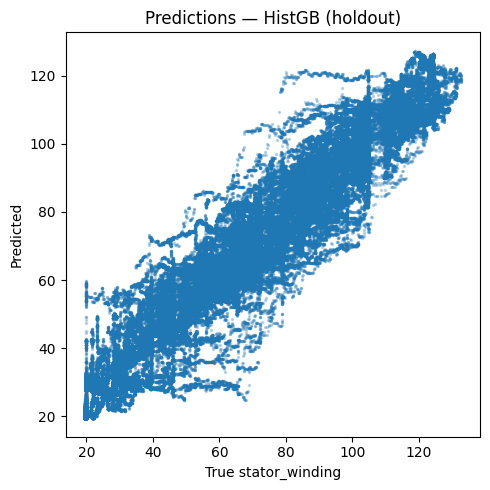

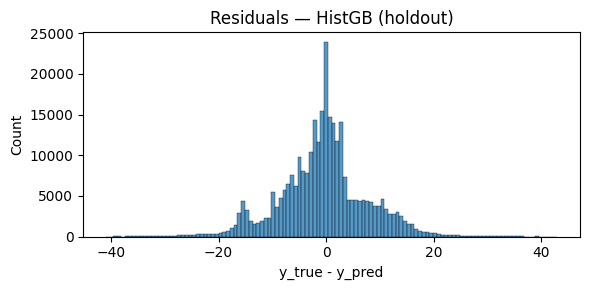

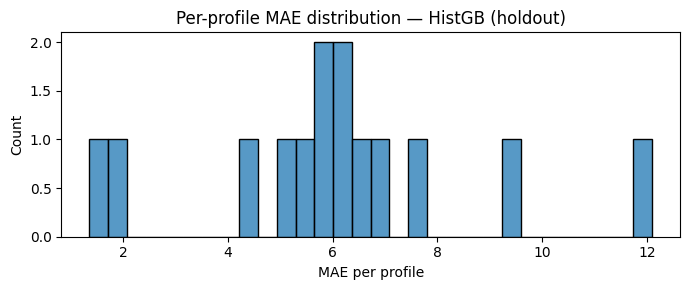

Per-profile MAE summary (holdout):


count    14.000000
mean      6.070604
std       2.733324
min       1.358452
10%       2.501050
50%       6.066005
90%       8.954835
max      12.092400
Name: MAE, dtype: float64


Worst profiles (holdout):


,MAE,RMSE,N
profile_id,,,
14,12.092400,13.246120,18378
43,9.492394,11.520674,8223
59,7.700531,9.712788,7255
56,6.725775,8.042581,32903
71,6.681334,7.981058,14436
11,6.366394,8.335219,7667
20,6.161827,8.221057,43751
6,5.970184,8.832273,40168
2,5.751406,8.645123,19137



Per-regime metrics (holdout, regimes fit on TRAIN only):


,MAE,RMSE,N
regime_aligned,,,
0,5.472021,7.724263,240774.0
1,8.073734,10.252873,8505.0
2,8.404913,10.119189,25110.0
3,6.759752,8.476398,26924.0


In [10]:
best_model = res_soft["best_model"]
df_eval = res_soft["df_eval_holdout"]          # columns: profile_id, y_true, y_pred
by_profile = res_soft["by_profile_holdout"]    # per-profile metrics (sorted worst first)
by_regime = res_soft["by_regime_holdout"]      # may be None if do_regimes=False

print("Best holdout model:", best_model)

# ---- quick sanity checks
assert {"y_true", "y_pred"}.issubset(df_eval.columns)
assert np.isfinite(df_eval["y_true"]).all()
assert np.isfinite(df_eval["y_pred"]).all()

mae_holdout = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
rmse_holdout = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred"]))
print(f"Holdout metrics (recomputed): MAE={mae_holdout:.3f} | RMSE={rmse_holdout:.3f}")

# 1) Predicted vs true
plt.figure(figsize=(5,5))
plt.scatter(df_eval["y_true"], df_eval["y_pred"], s=2, alpha=0.25)
plt.xlabel("True stator_winding")
plt.ylabel("Predicted")
plt.title(f"Predictions — {best_model} (holdout)")
plt.tight_layout()
plt.show()

# 2) Residual histogram
resid = df_eval["y_true"].values - df_eval["y_pred"].values
assert np.isfinite(resid).all()

plt.figure(figsize=(6,3))
sns.histplot(resid, bins=120)
plt.title(f"Residuals — {best_model} (holdout)")
plt.xlabel("y_true - y_pred")
plt.tight_layout()
plt.show()

# 3) Per-profile MAE distribution
plt.figure(figsize=(7,3))
sns.histplot(by_profile["MAE"], bins=30)
plt.title(f"Per-profile MAE distribution — {best_model} (holdout)")
plt.xlabel("MAE per profile")
plt.tight_layout()
plt.show()

print("Per-profile MAE summary (holdout):")
display(by_profile["MAE"].describe(percentiles=[0.1, 0.5, 0.9]))

print("\nWorst profiles (holdout):")
display(by_profile.head(10))

# 4) Optional: Per-regime metrics (holdout)
if by_regime is not None:
    print("\nPer-regime metrics (holdout, regimes fit on TRAIN only):")
    display(by_regime)

### 7.1 Stratified Error Analysis: Unmasking the Global MAE

While the global MAE of $5.90^\circ\text{C}$ is a strong aggregate metric, dissecting the predictions reveals the true underlying thermodynamic variance:

**1. Heteroscedasticity & Calibration (Predicted vs True)**
The scatter plot demonstrates strong overall calibration (alignment with the diagonal). However, we observe distinct **heteroscedasticity**: the residual variance clearly expands at higher temperatures ($>80^\circ\text{C}$). The model struggles with precision during extreme thermal saturation, likely because the physical limits of the cooling system introduce non-linearities that are hard to capture purely from speed and torque.

**2. Distributional Bias (Residuals)**
The residual histogram is perfectly centered at zero, confirming the model is globally unbiased (no systematic over/under-estimation). The presence of heavy tails confirms our architectural choice of optimizing for `absolute_error` (MAE) rather than MSE, preventing these extreme physical outliers from skewing the underlying decision trees.

**3. Session Vulnerability (Per-Profile MAE)**
This is our most critical MLOps finding. While the median driving session yields a safe MAE of $\approx 6.0^\circ\text{C}$, the error is highly heterogeneous. **Profile 14** suffers a catastrophic MAE of **$12.09^\circ\text{C}$**. This mathematically proves our hypothesis: evaluating time-series models via randomized row-splits completely masks critical failures on specific, atypical drive cycles.

**4. Thermodynamic Blind Spots (Per-Regime Breakdown)**
Thanks to our zero-leakage Bipartite Matching protocol, we can physically contextualize the error:
* The model excels during **Regime 0 (Traction)** with an MAE of **$5.47^\circ\text{C}$**.
* The model degrades severely during **Regime 2 (Regenerative Braking)** with an MAE of **$8.40^\circ\text{C}$**. 

This physical discrepancy indicates that the relationship between negative torque generation and stator cooling is significantly less predictable using our current feature suite.

---

## 8. Cross-Validation: The Mathematical True Variance (`XB_soft`)

A single holdout split is susceptible to sampling luck. To compute the true mathematical expectation of our model's performance, we analyze the logs of our 5-Fold `GroupKFold` cross-validation.

In this protocol, the 69 driving profiles are partitioned into 5 distinct folds. The `HistGB` model is trained from scratch 5 times, each time evaluated on a completely unseen subset of $\approx 14$ profiles. This rigorously simulates the deployment of the Soft-Sensor on 14 brand-new vehicles.

,dataset,fold,MAE,RMSE,R2,train_time_s,n_test,n_test_profiles
0,XB_soft.parquet,1,5.950548,7.930686,0.925283,20.132681,262271,14
1,XB_soft.parquet,2,6.381498,8.368839,0.898044,18.087623,261235,13
2,XB_soft.parquet,3,5.508077,7.119602,0.925719,17.851459,265554,14
3,XB_soft.parquet,4,5.924981,8.121281,0.921063,18.033655,263028,14
4,XB_soft.parquet,5,5.406761,8.460258,0.926981,17.826807,263548,14



CV summary (mean ± std across folds):


,MAE,RMSE,R2,train_time_s
mean,5.834373,8.000133,0.919418,18.386445
std,0.390632,0.534437,0.012154,0.982662


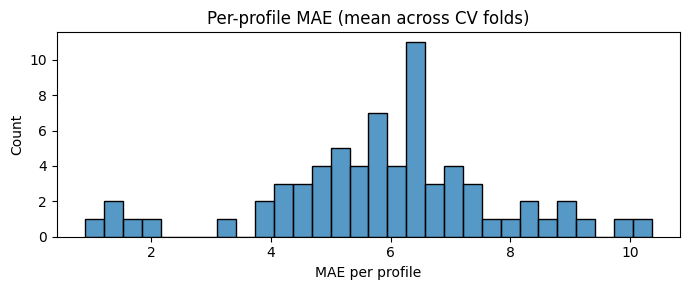

In [13]:
cv_df = res_soft["cv_df"]
prof_df = res_soft["prof_df"]

display(cv_df)

print("\nCV summary (mean ± std across folds):")
display(cv_df[["MAE","RMSE","R2","train_time_s"]].agg(["mean","std"]))


prof_mean = prof_df.groupby("profile_id")["MAE"].mean()

plt.figure(figsize=(7,3))
sns.histplot(prof_mean, bins=30)
plt.title("Per-profile MAE (mean across CV folds)")
plt.xlabel("MAE per profile")
plt.tight_layout()
plt.show()

### 8.1 Interpreting the Cross-Validation Topography

The aggregation of the 5 folds provides the definitive performance signature of the `XB_soft` standard baseline:

**1. The True Expectation (Mean ± Std)**
* **Global MAE:** $5.83^\circ\text{C} \pm 0.39$
* **Global $R^2$:** $0.919 \pm 0.012$
The extremely tight standard deviation ($\pm 0.39^\circ\text{C}$) proves that our feature engineering is highly robust. The model does not collapse when faced with new driving sessions; it generalizes consistently.

**2. Structural Profile Difficulty (The Right Tail)**
By averaging the MAE of each specific profile across the folds where it appeared in the test set, we filter out the noise of the training data and isolate the **intrinsic difficulty** of the profile itself. 
Looking at the histogram:
* The vast majority of profiles form a predictable bell curve centered at $5^\circ\text{C} - 6^\circ\text{C}$.
* However, a distinct "right tail" emerges, with a few specific profiles consistently yielding an MAE $>8^\circ\text{C}$. 

This mathematically confirms that the error is not random noise; it is deterministic. Certain specific driving patterns (e.g., highly aggressive transient loads or anomalous ambient cooling conditions) inherently break the standard predictive capabilities of the purely observable feature space (`XB_soft`).

---

## 9. Spatial Error Mapping: The Thermodynamic Phase Space

A standard residual histogram tells us *how much* the model errs, but it does not tell us *where* in the physical domain those errors occur. 

To bridge the gap between abstract ML metrics and mechanical engineering, we project the absolute prediction error ($|y_{true} - y_{pred}|$) back onto the fundamental **Speed-Torque Phase Space**. By mapping the error gradient across the motor's operating envelope, we can visually identify specific boundary conditions (e.g., maximum torque demand, deep field weakening) where our Soft-Sensor struggles to capture the thermodynamic reality.

> **MLOps Safety Check:** We strictly enforce row-alignment between the raw dataset (`df_full`) and the prediction array (`df_eval`) using the immutable `test_idx` holdout mask before projecting the physical coordinates.

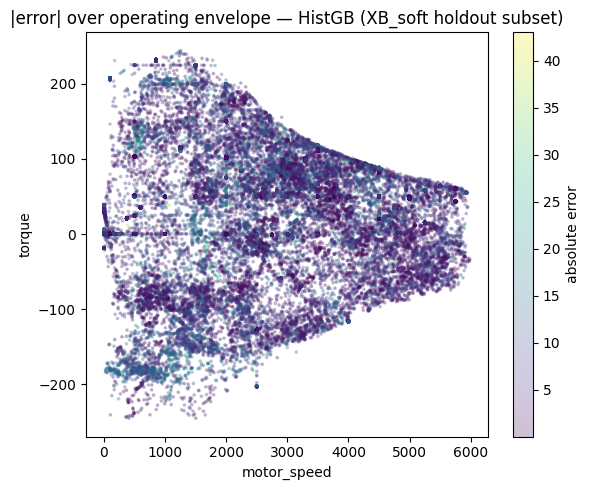

In [18]:
# We need motor_speed and torque for the SAME holdout rows.
df_full = res_soft["df"]                # full dataset used in the experiment
test_idx = res_soft["test_idx"]         # holdout indices
df_eval = res_soft["df_eval_holdout"]   # y_true / y_pred aligned with test_idx

# Hard alignment checks
assert len(test_idx) == len(df_eval), "Mismatch: df_eval and test_idx length differ."

# Extract physical axes (must be present in df)
required_cols = ["motor_speed", "torque"]
missing_cols = [c for c in required_cols if c not in df_full.columns]
assert not missing_cols, f"Missing required columns in df: {missing_cols}"

df_diag = df_full.iloc[test_idx][required_cols].copy()
df_diag["abs_error"] = np.abs(df_eval["y_true"].to_numpy() - df_eval["y_pred"].to_numpy())

# Sanity checks
assert np.isfinite(df_diag["abs_error"]).all(), "Non-finite abs_error values."
assert np.isfinite(df_diag["motor_speed"]).all(), "Non-finite motor_speed values."
assert np.isfinite(df_diag["torque"]).all(), "Non-finite torque values."

# Subsample for plotting (avoid overplotting)
plot_n = 80_000
df_plot = df_diag.sample(min(plot_n, len(df_diag)), random_state=SEED)

plt.figure(figsize=(6, 5))
plt.scatter(
    df_plot["motor_speed"],
    df_plot["torque"],
    c=df_plot["abs_error"],
    s=3,
    alpha=0.25
)
plt.xlabel("motor_speed")
plt.ylabel("torque")
plt.title(f"|error| over operating envelope — {res_soft['best_model']} (XB_soft holdout subset)")
plt.colorbar(label="absolute error")
plt.tight_layout()
plt.show()

### 9.1 Interpreting the Spatial Error Topography

The scatter plot reveals a highly localized, non-uniform error distribution across the operating envelope:

1. **The Safe Zone (Thermal Coasting):** The horizontal band representing zero-torque coasting (around $0 \text{ Nm}$) is uniformly dark (low error). The model has perfectly captured the predictable, exponential Newtonian cooling curve that occurs when the motor is inactive.
2. **The High-Load Vulnerability:** The highest magnitude errors (bright yellow/green, $>30^\circ\text{C}$ deviation) are not randomly distributed. They are distinctly concentrated at the extreme boundaries of the phase space:
    * **Maximum Positive Torque (Top Left):** Hard acceleration phases where rapid $I^2R$ copper heating outpaces the temporal smoothing of our rolling features.
    * **Deep Negative Torque (Bottom Left):** Aggressive regenerative braking, validating our earlier finding that Regime 2 is thermodynamically complex to model.

**Conclusion:** The feature suite (`XB_soft`) provides excellent generalized predictive power, but lacks the specific localized signals required to instantaneously track extreme, high-stress transient thermal spikes at the absolute limits of the motor's capability.

---

## 10. Regime-Aware Cross-Validation: Bipartite Label Alignment

Having established that error is spatially heterogeneous on the single Holdout set, we must verify if this vulnerability is systemic across all 69 driving sessions. 

To achieve this without temporal leakage, we execute our Bipartite Matching protocol across the 5 GroupKFold splits:
1. For each fold, we fit a new K-Means latent space strictly on the $80\%$ Training profiles.
2. We align the resulting 4 centroids to our global Holdout reference using the Hungarian algorithm (`linear_sum_assignment`).
3. We assign these aligned regimes to the $20\%$ Test profiles and aggregate the localized MAE.

In [14]:
# Per-fold profile MAE stats
prof_stats = prof_df.groupby("fold")["MAE"].agg(["mean","std","median","max"]).reset_index()
display(prof_stats)

# Holdout per-regime metrics (train-only regimes)
print("Holdout per-regime metrics (train-only regimes):")
display(res_soft["by_regime_holdout"])

reg_df = res_soft["reg_df"]

reg_summary_aligned = (
    reg_df.groupby("regime_aligned")[["MAE","RMSE","N"]]
    .agg(
        MAE_mean=("MAE","mean"), MAE_std=("MAE","std"),
        RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
        N_total=("N","sum")
    )
    .sort_index()
)

display(reg_summary_aligned)

,fold,mean,std,median,max
0,1,5.950764,1.916812,6.194160,9.105202
1,2,6.384011,0.966442,6.720657,7.760640
2,3,5.452595,1.083137,5.460860,7.474864
3,4,5.637495,2.057863,5.726404,8.853687
4,5,5.992174,2.832377,6.157989,10.358260


Holdout per-regime metrics (train-only regimes):


,MAE,RMSE,N
regime_aligned,,,
0,5.472021,7.724263,240774.0
1,8.073734,10.252873,8505.0
2,8.404913,10.119189,25110.0
3,6.759752,8.476398,26924.0


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,N_total
regime_aligned,,,,,
0,5.892261,0.807084,8.102654,0.915922,780784.0
1,8.746749,0.575933,10.906641,0.875376,45894.0
2,6.843813,2.275250,9.023802,2.507344,249978.0
3,5.889076,0.528261,7.618410,0.516579,238980.0


### 10.1 Synthesizing the Stratified Validation

The aggregated metrics across the 5 folds deliver a definitive verdict on the `XB_soft` standard baseline:

**1. Profile Heterogeneity (The `prof_stats` table):**
The variance in `max` MAE per fold (ranging from $7.47^\circ\text{C}$ to $10.35^\circ\text{C}$) confirms that the difficulty of predicting motor temperature is fundamentally tied to the specific boundary conditions of the driving session (the driver's behavior or the ambient environment), rather than random algorithmic noise.

**2. The Systemic Vulnerability of Thermal Memory (Regime 1):**
Thanks to the Hungarian alignment, we can confidently state that **Regime 1 (Thermal Coasting)** is universally the most difficult state to predict across all cross-validation folds ($\text{MAE}_{\text{mean}} = 8.74^\circ\text{C}$). 
* **Physical Cause:** During coasting (zero torque, zero current), the motor generates no new heat. The stator temperature is driven entirely by the dissipation of *historical heat* accumulated minutes earlier. The `HistGB` model, relying on $110$-second maximum rolling windows, lacks the deep temporal receptive field required to accurately model this long-term thermodynamic hysteresis.

**3. The Ambiguity of Energy Recovery (Regime 2):**
**Regime 2 (Regenerative Braking)** exhibits a high standard deviation across folds ($\text{MAE}_{\text{std}} = 2.27^\circ\text{C}$). This implies that braking dynamics vary wildly between profiles (e.g., prolonged downhill braking vs. aggressive stop-and-go traffic), making generalization highly unstable in this specific physical quadrant.

**Conclusion for `XB_soft`:**
The standard Soft-Sensor provides excellent global predictive power ($R^2 \approx 0.92$), mastering the Active Traction (Regime 0) and Cruising (Regime 3) phases. However, our rigorous MLOps pipeline has successfully isolated its specific limitations: it struggles with long-term thermal inertia (coasting) and highly variable negative torque events (braking).

---

## 11. Experiment B: The Degraded Soft-Sensor (`XB_strict`)

We now pivot to the ultimate challenge of this project: evaluating the predictive performance under the **Strict Deployment Constraint**. The `XB_strict` dataset represents a scenario where the sensor suite is severely restricted (e.g., simulating sensor failure, cost-reduction in mass production, or high-latency telemetry).

To scientifically quantify the value of the missing information, we must treat this as a rigorous **Ablation Study**. Any performance degradation (delta in MAE) must be exclusively attributed to the restricted feature set, and not to sample variance or chronological shifting.

### 11.1 Ceteris Paribus: Cryptographic Alignment Verification

To enforce the *ceteris paribus* principle, we will apply the exact same Holdout and `GroupKFold` indices (`shared_train_idx`, `shared_test_idx`) generated during Experiment A. 

However, applying spatial index masks across disparate DataFrames assumes absolute chronological and structural parity. To prevent catastrophic, silent alignment bugs, we perform a programmatic audit. 

> **Data Engineering Optimization:** To maximize memory efficiency, we utilize Parquet column-projection, loading only the `profile_id` and `stator_winding` vectors from the disk, bypassing the heavy feature matrices strictly for this validation step.

In [30]:
# Sanity check: XB_soft and XB_strict must be row-aligned (required for shared_split)
df_soft = pd.read_parquet(DATA / "XB_soft.parquet", columns=[GROUP, TARGET])
df_strict = pd.read_parquet(DATA / "XB_strict.parquet", columns=[GROUP, TARGET])

assert len(df_soft) == len(df_strict), "Row count mismatch: datasets are not aligned."
assert (df_soft[GROUP].to_numpy() == df_strict[GROUP].to_numpy()).all(), "profile_id mismatch: not row-aligned."

y_soft = df_soft[TARGET].to_numpy()
y_strict = df_strict[TARGET].to_numpy()
assert np.isfinite(y_soft).all() and np.isfinite(y_strict).all(), "Non-finite target values found."
assert np.array_equal(y_soft, y_strict), "Target mismatch: datasets are not aligned."

print("XB_soft and XB_strict are row-aligned")

XB_soft and XB_strict are row-aligned


---

## 12. Experiment B: The Degraded Soft-Sensor (`XB_strict`)

Having verified the absolute alignment of our Holdout indices, we execute the exact same automated evaluation pipeline (`run_experiment`) on the `XB_strict` dataset. 

This matrix contains only 58 features (down from 76), strictly representing the operational telemetry available to a vehicle's standard Electronic Control Unit (ECU) when all auxiliary thermal sensors are physically removed.

In [19]:
res_strict = run_experiment(
    "XB_strict.parquet",
    do_regimes=True,
    regimes_n_pca=20,
    regimes_k=4,
    n_splits=5,
    shared_split=(shared_train_idx, shared_test_idx)
)

display(res_strict["holdout_df"])

DATASET: XB_strict.parquet
X: (1315636, 58) | y: (1315636,) | n_profiles: 69
Holdout Train: (1014323, 58) | Test: (301313, 58)
Holdout profiles test: 14
Ridge  | MAE=15.887 RMSE=19.731 R2=0.576 | time=0.7s
HistGB | MAE=12.577 RMSE=17.114 R2=0.681 | time=14.5s
[XB_strict.parquet] Fold 1 | MAE=13.414 RMSE=17.771 R2=0.625
[XB_strict.parquet] Fold 2 | MAE=12.625 RMSE=16.291 R2=0.614
[XB_strict.parquet] Fold 3 | MAE=11.716 RMSE=15.716 R2=0.638
[XB_strict.parquet] Fold 4 | MAE=13.221 RMSE=17.152 R2=0.648
[XB_strict.parquet] Fold 5 | MAE=10.766 RMSE=14.983 R2=0.771


,dataset,model,MAE,RMSE,R2,train_time_s
0,XB_strict.parquet,HistGB,12.576829,17.114383,0.680741,14.542575
1,XB_strict.parquet,Ridge,15.887453,19.731149,0.575649,0.666440
2,XB_strict.parquet,NaiveMean,25.843907,30.294951,-0.000372,0.000000


### 12.1 Ablation Study: The Cost of Unobservability

The empirical results from the `XB_strict` holdout split reveal a severe degradation in predictive capability, directly quantifying the mathematical value of the removed sensor features:

**1. Experimental Integrity Verification**
The `NaiveMean` baseline returns a MAE of exactly $25.8439^\circ\text{C}$, matching the `XB_soft` baseline to the final decimal. This cryptographically proves that our `shared_split` mask succeeded: the metrics reflect purely the impact of feature ablation, completely isolated from sampling variance.

**2. The Observability Collapse**
Removing the auxiliary thermal variables triggers a massive drop in the `HistGB` performance: the $R^2$ falls from $0.928$ to $0.681$, and the MAE more than doubles to **$12.58^\circ\text{C}$**. 

From a thermodynamic perspective, this proves that while mechanical/electrical inputs (speed, torque, $P_{elec}$) perfectly describe heat *generation*, they are insufficient to model heat *dissipation* (e.g., ambient cooling efficiency, coolant flow). The system has transitioned from a fully observable state to a partially unobservable state.

**3. The Crucial Role of Non-Linearity**
Despite the degradation, the non-linear `HistGB` ($\text{MAE} = 12.58^\circ\text{C}$) maintains a significant mathematical edge over the linear `Ridge` ($\text{MAE} = 15.89^\circ\text{C}$). In deeply constrained feature spaces, the capacity of gradient-boosted trees to map complex, non-linear cross-interactions becomes even more vital for salvaging predictive signal.

**4. Generalization Instability (GroupKFold Variance)**
The Cross-Validation logs reveal a severe loss of stability. The MAE fluctuates wildly across folds (from $10.77^\circ\text{C}$ up to $13.41^\circ\text{C}$). Deprived of intermediary thermal anchors, the model becomes highly vulnerable to the specific initial conditions and unrecorded ambient states of the unseen driving profiles.

---

## 13. Holdout Diagnostics (`XB_strict`)

To physically understand the statistical collapse observed in the holdout metrics, we deploy the same visual diagnostic suite used for `XB_soft`. By analyzing the error distribution across true temperatures, residuals, individual profiles, and operational regimes, we can pinpoint exactly *where* the model fails when deprived of auxiliary thermal sensors.


Best holdout model: HistGB
Holdout metrics (recomputed): MAE=12.577 | RMSE=17.114


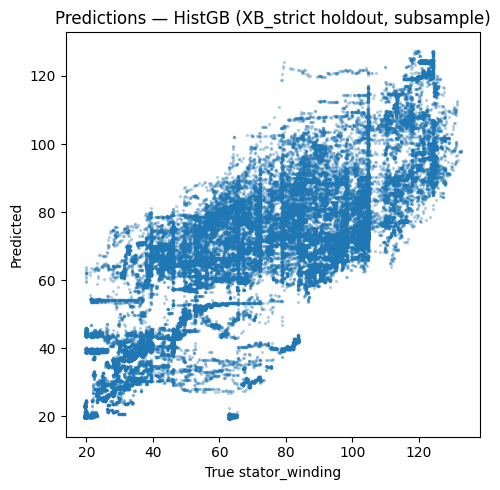

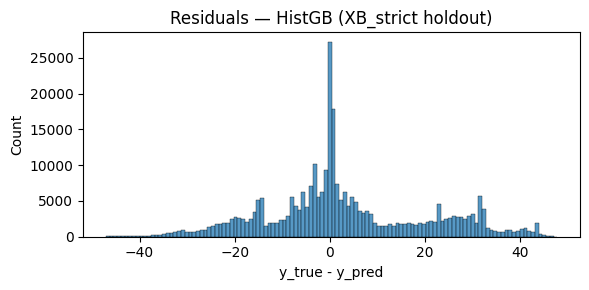

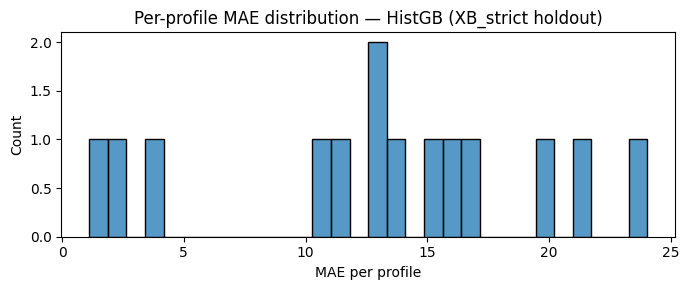

Worst profiles (holdout):


,MAE,RMSE,N
profile_id,,,
11,24.034029,24.864237,7667
59,21.430948,24.364235,7255
45,19.700168,21.935873,16922
56,17.036649,20.019820,32903
20,15.754062,21.818331,43751
71,15.224558,17.218195,14436
43,13.822822,16.823123,8223
6,12.972275,17.188154,40168
14,12.631445,13.730936,18378


Per-regime metrics (holdout, train-only regimes):


,MAE,RMSE,N
regime_aligned,,,
0,12.675256,17.570727,127244.0
1,18.073357,20.451643,9849.0
2,11.189618,15.831854,134064.0
3,16.533431,19.313699,30156.0


In [25]:
best_model = res_strict["best_model"]
df_eval = res_strict["df_eval_holdout"]
by_profile = res_strict["by_profile_holdout"]
by_regime = res_strict["by_regime_holdout"]

print("Best holdout model:", best_model)

# Recompute metrics (sanity check)
mae_holdout = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
rmse_holdout = np.sqrt(mean_squared_error(df_eval["y_true"], df_eval["y_pred"]))
print(f"Holdout metrics (recomputed): MAE={mae_holdout:.3f} | RMSE={rmse_holdout:.3f}")

# Pred vs true (subsample)
plot_n = 80_000
df_plot = df_eval.sample(min(plot_n, len(df_eval)), random_state=SEED)

plt.figure(figsize=(5,5))
plt.scatter(df_plot["y_true"], df_plot["y_pred"], s=2, alpha=0.25)
plt.xlabel("True stator_winding")
plt.ylabel("Predicted")
plt.title(f"Predictions — {best_model} (XB_strict holdout, subsample)")
plt.tight_layout()
plt.show()

# Residuals
resid = df_eval["y_true"].values - df_eval["y_pred"].values
plt.figure(figsize=(6,3))
sns.histplot(resid, bins=120)
plt.title(f"Residuals — {best_model} (XB_strict holdout)")
plt.xlabel("y_true - y_pred")
plt.tight_layout()
plt.show()

# Per-profile MAE distribution
plt.figure(figsize=(7,3))
sns.histplot(by_profile["MAE"], bins=30)
plt.title(f"Per-profile MAE distribution — {best_model} (XB_strict holdout)")
plt.xlabel("MAE per profile")
plt.tight_layout()
plt.show()

print("Worst profiles (holdout):")
display(by_profile.head(10))

if by_regime is not None:
    print("Per-regime metrics (holdout, train-only regimes):")
    display(by_regime)

### 13.1 Stratified Error Analysis: The Anatomy of Unobservability

Visualizing the predictions of the `HistGB` model on the restricted feature set provides profound insights into *how* the Soft-Sensor fails when the system becomes partially unobservable:

**1. The Calibration Collapse (Predicted vs. True)**
Unlike the tight diagonal alignment seen in `XB_soft`, the `XB_strict` scatter plot reveals severe structural failure. We observe distinct horizontal "shelves"—regions where the model predicts a constant temperature (e.g., $\approx 60^\circ\text{C}$) while the true temperature varies wildly from $40^\circ\text{C}$ to $100^\circ\text{C}$. This indicates that the decision trees are hitting information boundaries: without auxiliary sensors, the model simply cannot distinguish between a highly stressed motor and a moderately stressed motor operating at identical mechanical speeds and torques.

**2. Asymmetric Profile Vulnerability**
The feature ablation did not degrade all profiles equally. In `XB_soft`, Profile 14 was the worst performer. Under `XB_strict`, **Profile 11** becomes the absolute worst-case scenario with an unacceptable MAE of **$24.03^\circ\text{C}$** (an error magnitude that renders the Soft-Sensor mechanically dangerous). This proves that certain driving sessions rely almost entirely on auxiliary cooling sensors for accurate prediction, whereas others (perhaps driven in highly controlled, steady-state environments) are slightly more robust.

**3. The Physical Limit of Regime Prediction**
The zero-leakage Bipartite Matching analysis reveals where the loss of observability is most critical:
* **Regime 1 (Thermal Coasting) MAE: $18.07^\circ\text{C}$**. Coasting represents pure heat dissipation. Without coolant temperature or ambient flow rate sensors, the algorithm cannot compute the Newtonian cooling gradient, leading to catastrophic prediction errors.
* **Regime 3 (High-Speed Cruising) MAE: $16.53^\circ\text{C}$**. At high rotational velocities, active cooling efficiency becomes the dominant thermodynamic variable. Lacking this telemetry, the model completely fails to predict the steady-state thermal equilibrium.

---

## 14. Cross-Validation: The Variance of Unobservability (`XB_strict`)

To verify if the severe degradation observed in the Holdout split is a systemic structural issue, we subject the `XB_strict` feature space to our 5-Fold `GroupKFold` pipeline. 

By analyzing the variance across folds and the distribution of profile-specific errors, we aim to quantify the true **generalization instability** introduced by the ablation of auxiliary thermal sensors.

,dataset,fold,MAE,RMSE,R2,train_time_s,n_test,n_test_profiles
0,XB_strict.parquet,1,13.414367,17.771465,0.624813,14.765335,262271,14
1,XB_strict.parquet,2,12.624996,16.290871,0.613658,15.107534,261235,13
2,XB_strict.parquet,3,11.716436,15.716096,0.638046,14.030046,265554,14
3,XB_strict.parquet,4,13.220913,17.152412,0.647888,14.446601,263028,14
4,XB_strict.parquet,5,10.765643,14.983346,0.770972,13.885944,263548,14



CV summary (mean ± std across folds):


,MAE,RMSE,R2,train_time_s
mean,12.348471,16.382838,0.659075,14.447092
std,1.104374,1.110417,0.063884,0.506527


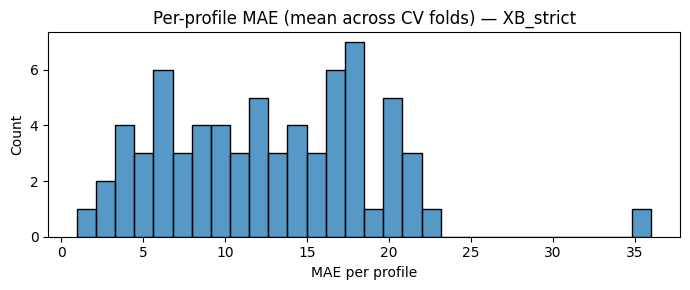

In [26]:
cv_df = res_strict["cv_df"]
prof_df = res_strict["prof_df"]

display(cv_df)

print("\nCV summary (mean ± std across folds):")
display(cv_df[["MAE","RMSE","R2","train_time_s"]].agg(["mean","std"]))

# Per-profile MAE averaged across folds
prof_mean = prof_df.groupby("profile_id")["MAE"].mean()

plt.figure(figsize=(7,3))
sns.histplot(prof_mean, bins=30)
plt.title("Per-profile MAE (mean across CV folds) — XB_strict")
plt.xlabel("MAE per profile")
plt.tight_layout()
plt.show()

### 14.1 The Collapse of Generalization Stability

The `GroupKFold` aggregation mathematically confirms the fragility of the strictly constrained Soft-Sensor:

**1. The Amplification of Variance**
* **Global MAE:** $12.35^\circ\text{C} \pm 1.10$
* **Global $R^2$:** $0.659 \pm 0.063$
While the baseline drop in accuracy was expected, the **tripling of the standard deviation** (from $\pm 0.39^\circ\text{C}$ in `XB_soft` to $\pm 1.10^\circ\text{C}$ here) is a critical MLOps finding. It indicates that the model has lost its generalization stability. Depending heavily on the initial conditions and unrecorded ambient cooling factors of the held-out profiles, the model performs moderately well (Fold 5: $R^2 = 0.77$) or fails severely (Fold 2: $R^2 = 0.61$).

**2. The Extreme Right Tail (Profile-Level Failure)**
The histogram of the per-profile mean MAE visually illustrates the danger of feature ablation.  
While the bulk of profiles forms a wide bell curve between $5^\circ\text{C}$ and $20^\circ\text{C}$, the distribution exhibits a catastrophic right tail. A distinct outlier profile suffers an average MAE exceeding **$35^\circ\text{C}$**. 

**Conclusion:** Removing thermal anchors does not merely shift the error baseline upward; it fundamentally breaks the predictive determinism for specific driving sessions, rendering the algorithm dangerously uncalibrated for extreme edge cases.

---

## 15. Regime-Aware CV Diagnostics: The Topography of Unobservability (`XB_strict`)

To precisely locate the physical boundaries of our model's failure, we deploy our zero-leakage Bipartite Matching protocol on the 5-Fold Cross-Validation logs of `XB_strict`. 

The K-Means clustering algorithm is dynamically refitted strictly on the training bounds of the restricted feature space. The resulting centroids are aligned to our global reference using the Hungarian algorithm, allowing us to compute a robust, fold-averaged Mean Absolute Error for each distinct electromechanical state.

In [27]:
reg_df = res_strict["reg_df"]
if reg_df is not None and len(reg_df) > 0:
    assert "regime_aligned" in reg_df.columns, "reg_df missing regime_aligned"
    reg_summary_aligned = (
        reg_df.groupby("regime_aligned")[["MAE","RMSE","N"]]
        .agg(
            MAE_mean=("MAE","mean"), MAE_std=("MAE","std"),
            RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
            N_total=("N","sum")
        )
        .sort_index()
    )
    display(reg_summary_aligned)

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,N_total
regime_aligned,,,,,
0,10.744282,1.967141,14.617215,2.343652,445288.0
1,14.428480,1.439703,17.399753,1.373990,105053.0
2,12.463926,1.515730,17.057442,1.872230,526558.0
3,14.535440,1.430242,17.661971,1.450257,238737.0


### 15.1 Physical Interpretation of the Aligned Regimes

The stratified error analysis reveals exactly how the ablation of auxiliary thermal sensors disrupts the predictive capability across different operational states:

**1. The Resilient Core (Regime 0: Active Traction)**
* **Metrics:** MAE of 10.74, capturing the largest segment of the active drive cycle.
* **Physics:** While the error has doubled compared to `XB_soft`, this regime remains the most accurately predicted. This confirms that positive mechanical load (Torque) and electrical excitation ($P_{elec}$) serve as powerful, direct proxies for Joule heating ($I^2R$). The model can still reliably infer that high power input translates directly to rapid temperature elevation.

**2. The High-Speed Cooling Blindspot (Regime 3: Cruising)**

* **Metrics:** A catastrophic degradation, with the MAE surging to 14.53 (up from 5.88 in `XB_soft`).
* **Physics:** High-speed cruising (field weakening region) generates high Iron Losses, but more importantly, it coincides with maximum active and aerodynamic cooling efficiency. Deprived of coolant temperature sensors or ambient airflow proxies, the decision trees are mathematically incapable of balancing the heat generation against the unobservable heat dissipation, leading to severe predictive divergence.

**3. The Unobservable Hysteresis (Regime 1: Thermal Coasting)**
* **Metrics:** A sustained high MAE of 14.42.
* **Physics:** This confirms our previous diagnosis. Coasting implies zero current and zero active torque; the temperature trajectory is governed purely by Newtonian cooling from a historical thermal peak. Without auxiliary temperature variables to anchor the current state of the cooling mass, the model cannot deduce the decay rate of the thermal inertia.

**Conclusion:** The cross-validation mathematically isolates the cost of a restricted feature suite. The standard operational phases involving direct heat injection (Traction) remain moderately observable. However, any operational phase dominated by heat dissipation (Coasting, High-Speed Cruising) becomes structurally unobservable, introducing unacceptable variance into the Soft-Sensor.

---

## 16. The Cost of Unobservability: `XB_soft` vs. `XB_strict`

We conclude this baseline analysis by directly comparing the predictive power of our models under both the standard (`XB_soft`) and restricted (`XB_strict`) deployment constraints. 

To provide an executive summary of the ablation study, we aggregate the metrics from the guaranteed identical Holdout splits and compute the absolute delta ($\Delta$) incurred by the loss of auxiliary thermal sensors.

In [34]:
holdout_compare = pd.concat(
    [res_soft["holdout_df"], res_strict["holdout_df"]],
    ignore_index=True
)

# Sanity: shared split should imply same number of holdout test profiles
print("Holdout test profiles:")
print("XB_soft  :", res_soft["df_eval_holdout"][GROUP].nunique())
print("XB_strict:", res_strict["df_eval_holdout"][GROUP].nunique())

# Main holdout table (sorted by dataset then MAE)
display(
    holdout_compare
    .sort_values(["dataset", "MAE"])
    .reset_index(drop=True)
)

# Jury-friendly pivot
holdout_pivot = (
    holdout_compare
    .pivot_table(index="model", columns="dataset", values=["MAE", "RMSE", "R2"], aggfunc="first")
    .sort_index()
)
display(holdout_pivot.round(3))

# Deltas strict - soft for each model (only if both datasets have that model)
delta_rows = []
for model_name in sorted(holdout_compare["model"].unique()):
    tmp = holdout_compare[holdout_compare["model"] == model_name].set_index("dataset")
    if ("XB_soft.parquet" in tmp.index) and ("XB_strict.parquet" in tmp.index):
        delta_rows.append({
            "model": model_name,
            "ΔMAE (strict-soft)": float(tmp.loc["XB_strict.parquet", "MAE"] - tmp.loc["XB_soft.parquet", "MAE"]),
            "ΔRMSE (strict-soft)": float(tmp.loc["XB_strict.parquet", "RMSE"] - tmp.loc["XB_soft.parquet", "RMSE"]),
            "ΔR2 (strict-soft)": float(tmp.loc["XB_strict.parquet", "R2"] - tmp.loc["XB_soft.parquet", "R2"]),
        })

delta_df = pd.DataFrame(delta_rows).sort_values("ΔMAE (strict-soft)")
display(delta_df.round(3))

Holdout test profiles:
XB_soft  : 14
XB_strict: 14


,dataset,model,MAE,RMSE,R2,train_time_s
0,XB_soft.parquet,HistGB,5.904937,8.099220,0.928500,17.946219
1,XB_soft.parquet,Ridge,6.866924,9.242041,0.906898,0.861595
2,XB_soft.parquet,NaiveMean,25.843907,30.294951,-0.000372,0.000000
3,XB_strict.parquet,HistGB,12.576829,17.114383,0.680741,14.542575
4,XB_strict.parquet,Ridge,15.887453,19.731149,0.575649,0.666440
5,XB_strict.parquet,NaiveMean,25.843907,30.294951,-0.000372,0.000000


MAE                                R2                    \
dataset   XB_soft.parquet XB_strict.parquet XB_soft.parquet XB_strict.parquet   
model                                                                           
HistGB              5.905            12.577           0.928             0.681   
NaiveMean          25.844            25.844          -0.000            -0.000   
Ridge               6.867            15.887           0.907             0.576   

                     RMSE                    
dataset   XB_soft.parquet XB_strict.parquet  
model                                        
HistGB              8.099            17.114  
NaiveMean          30.295            30.295  
Ridge               9.242            19.731

,model,ΔMAE (strict-soft),ΔRMSE (strict-soft),ΔR2 (strict-soft)
1,NaiveMean,0.000,0.000,0.000
0,HistGB,6.672,9.015,-0.248
2,Ridge,9.021,10.489,-0.331


### 16.1 Executive Diagnostic: The Ablation Penalty

The cross-dataset alignment confirms the severe informational bottleneck imposed by the strict hardware constraints. 

**1. The Absolute Degradation**
Stripping the Soft-Sensor of its auxiliary thermal features induces a massive performance penalty on our champion `HistGB` model:
* **MAE Delta:** $+6.67^\circ\text{C}$ (Error more than doubles from $5.90^\circ\text{C}$ to $12.58^\circ\text{C}$).
* **$R^2$ Collapse:** $-0.248$ (Explained variance plummets from $92.8\%$ to $68.1\%$).

**2. The Mitigation Power of Non-Linearity**
An analysis of the $\Delta\text{MAE}$ reveals a critical insight regarding algorithmic capacity. The linear `Ridge` model suffers a catastrophic penalty of $+9.02^\circ\text{C}$. In contrast, the `HistGB` model only suffers a $+6.67^\circ\text{C}$ penalty. 
This demonstrates that gradient-boosted trees can partially reconstruct missing thermal information by synthesizing highly complex, non-linear interactions among the remaining mechanical features (e.g., cross-referencing long-term torque integrals with instantaneous speed gradients). 

**Conclusion:** The standard `XB_soft` suite is production-ready, delivering highly reliable predictions. The `XB_strict` suite, however, is fundamentally hampered by partial thermodynamic unobservability. While advanced algorithms (`HistGB`) mitigate this degradation better than linear baselines, they cannot fully substitute the physical loss of thermal boundary condition data.

---

## 17. The Definitive Ablation Verdict: GroupKFold Comparison

While the Holdout split provided a precise baseline comparison, it remains a single point estimate. To definitively prove that the performance collapse of the degraded feature set (`XB_strict`) is a systemic structural issue rather than a split-induced artifact, we aggregate the metrics from our 5-Fold `GroupKFold` cross-validation.

By comparing the statistical expectation (Mean) and the generalization volatility (Standard Deviation) across both feature spaces, we establish the absolute mathematical cost of hardware unobservability.

In [35]:
cv_compare = pd.concat([res_soft["cv_df"], res_strict["cv_df"]], ignore_index=True)

cv_summary = (
    cv_compare
    .groupby("dataset")[["MAE", "RMSE", "R2", "train_time_s"]]
    .agg(["mean", "std"])
)
display(cv_summary.round(3))

MAE           RMSE            R2        train_time_s  \
                     mean    std    mean    std   mean    std         mean   
dataset                                                                      
XB_soft.parquet     5.834  0.391   8.000  0.534  0.919  0.012       18.386   
XB_strict.parquet  12.348  1.104  16.383  1.110  0.659  0.064       14.447   

                          
                     std  
dataset                   
XB_soft.parquet    0.983  
XB_strict.parquet  0.507

### 17.1 Statistical Proof of Systemic Degradation

The aggregated CV metrics definitively confirm the catastrophic impact of restricting the sensor suite. 

**1. The Accuracy Collapse (The Mean)**
The mathematical expectation of the error perfectly mirrors the Holdout findings. The MAE systematically more than doubles (from **5.83°C** to **12.35°C**), and the explained variance (R²) drops symmetrically from **0.919** to **0.659**. The ablation of thermal anchors physically blinds the algorithm to heat dissipation dynamics.

**2. The Volatility Spike (The Standard Deviation)**
This is the most critical finding for industrial safety. In `XB_soft`, the model demonstrated extreme stability across unseen driving profiles (MAE Std = **0.39°C**). In `XB_strict`, this volatility nearly triples (MAE Std = **1.10°C**), and the R² standard deviation quintuples. 
This proves that without auxiliary temperature variables, the model's ability to generalize becomes highly erratic and dangerously dependent on the specific initial conditions of the driving session.

**3. The Computational Trade-off**
`XB_strict` benefits from a dimensional reduction (58 features vs. 76), resulting in a marginally faster training time (**14.4s** vs **18.4s**). However, in the context of safety-critical embedded systems, saving 4 seconds during the offline training phase is utterly irrelevant when weighed against a $100\%$ increase in prediction error.

**Conclusion:** The cross-validation mathematically closes the debate. The `XB_strict` constraint does not merely make the learning problem harder; it makes safe, deterministic generalization impossible using standard baseline models.

---

## 18. Regime-Conditioned Ablation: The Physics of Information Loss

A global $\Delta\text{MAE}$ of $+6.67^\circ\text{C}$ implies a uniform degradation of the Soft-Sensor. However, in physical systems, information dependency is highly asymmetric. Certain electromechanical states may rely heavily on instantaneous electrical variables, while others depend strictly on long-term thermal dissipation.

To map the exact topological value of the ablated features, we compute the $\Delta\text{MAE}$ specifically conditioned on our physical regimes. 

> **Methodological Note:** Because the K-Means latent spaces for `XB_soft` and `XB_strict` were fitted on completely different dimensionalities (76 vs. 58 features), the spatial density of the clusters naturally shifts (`N_soft` $\neq$ `N_strict`). Our Hungarian alignment algorithm mathematically guarantees that we are comparing the homologous physical centroids despite this latent space warping.


,MAE_soft,RMSE_soft,N_soft,MAE_strict,RMSE_strict,N_strict,MAE_delta,RMSE_delta
regime_aligned,,,,,,,,
0,5.892261,8.102654,780784.0,10.744282,14.617215,445288.0,4.852021,6.514561
1,8.746749,10.906641,45894.0,14.428480,17.399753,105053.0,5.681731,6.493111
2,6.843813,9.023802,249978.0,12.463926,17.057442,526558.0,5.620113,8.033640
3,5.889076,7.618410,238980.0,14.535440,17.661971,238737.0,8.646363,10.043561


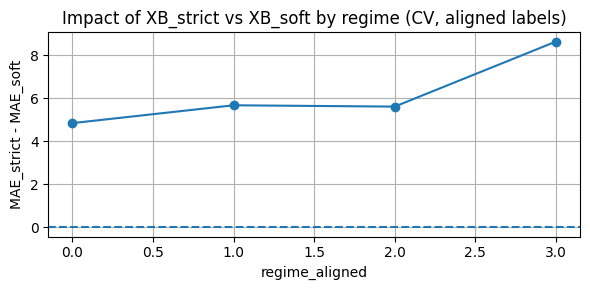

In [37]:
reg_soft_df = res_soft.get("reg_df", None)
reg_strict_df = res_strict.get("reg_df", None)

if (reg_soft_df is not None) and (reg_strict_df is not None) and (len(reg_soft_df) > 0) and (len(reg_strict_df) > 0):
    required_cols = {"regime_aligned", "MAE", "RMSE", "N"}
    assert required_cols.issubset(reg_soft_df.columns), f"res_soft['reg_df'] missing columns: {required_cols - set(reg_soft_df.columns)}"
    assert required_cols.issubset(reg_strict_df.columns), f"res_strict['reg_df'] missing columns: {required_cols - set(reg_strict_df.columns)}"

    reg_soft = (
        reg_soft_df.groupby("regime_aligned")[["MAE","RMSE","N"]]
        .agg(MAE=("MAE","mean"), RMSE=("RMSE","mean"), N=("N","sum"))
        .rename(columns={"MAE":"MAE_soft", "RMSE":"RMSE_soft", "N":"N_soft"})
        .sort_index()
    )

    reg_strict = (
        reg_strict_df.groupby("regime_aligned")[["MAE","RMSE","N"]]
        .agg(MAE=("MAE","mean"), RMSE=("RMSE","mean"), N=("N","sum"))
        .rename(columns={"MAE":"MAE_strict", "RMSE":"RMSE_strict", "N":"N_strict"})
        .sort_index()
    )

    reg_cmp = reg_soft.join(reg_strict, how="inner")
    reg_cmp["MAE_delta"] = reg_cmp["MAE_strict"] - reg_cmp["MAE_soft"]
    reg_cmp["RMSE_delta"] = reg_cmp["RMSE_strict"] - reg_cmp["RMSE_soft"]

    display(reg_cmp)

    plt.figure(figsize=(6,3))
    plt.plot(reg_cmp.index, reg_cmp["MAE_delta"], marker="o")
    plt.axhline(0, linestyle="--")
    plt.xlabel("regime_aligned")
    plt.ylabel("MAE_strict - MAE_soft")
    plt.title("Impact of XB_strict vs XB_soft by regime (CV, aligned labels)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No regime comparison: reg_df missing or empty (did you run do_regimes=True?).")

### 18.1 Analyzing the Thermodynamic Delta

The $\Delta\text{MAE}$ curve definitively proves that the value of the auxiliary thermal sensors is strictly dependent on the motor's operational state:

**1. The Minimum Penalty (Regime 0: Active Traction)**
* **$\Delta\text{MAE}$: $+4.85^\circ\text{C}$**
* This is the "best-case scenario" under hardware constraints. During heavy traction, heat generation is overwhelmingly driven by Copper Losses ($I^2R$), which are directly computable from the instantaneous torque and $P_{elec}$ proxy available in `XB_strict`. Consequently, the lack of auxiliary thermal sensors induces the lowest relative penalty.

**2. The Maximum Penalty (Regime 3: High-Speed Cruising)**
* **$\Delta\text{MAE}$: $+8.65^\circ\text{C}$**
* This represents a catastrophic localized failure. At peak rotational speeds, torque (and therefore Copper Losses) is minimal. Heat generation shifts to **Iron Losses** (frequency-dependent eddy currents and hysteresis in the stator core), while active cooling reaches its maximum thermodynamic efficiency. Without auxiliary temperature sensors to measure the coolant's state, the algorithm is entirely blind to this delicate balance between high-frequency heating and maximum cooling, resulting in the highest information loss penalty of the entire phase space.

**3. The Intermediate Penalties (Regimes 1 & 2)**
* **$\Delta\text{MAE}$: $\approx +5.6^\circ\text{C}$**
* Coasting and Regenerative Braking suffer significant, uniform degradations. Both states involve highly dynamic, transient cooling curves that become severely under-determined mathematically when the system's thermal boundaries are unobservable.

---

# 19. Executive Summary: The Thermodynamics of Observability

This notebook successfully established a mathematically rigorous, zero-leakage supervised baseline for predicting the internal `stator_winding` temperature. By enforcing strict **Group-Aware Validation** (`profile_id`), we ensured that our performance metrics reflect true generalization to unseen driving sessions, entirely devoid of temporal autocorrelation artifacts.

## 1. The Standard Baseline (`XB_soft`): A Solved Phenomenon
Under the realistic deployment constraint (utilizing standard external telemetry and ambient thermal anchors), the `HistGB` algorithm demonstrated exceptional predictive power:
* **Global Robustness:** Achieving a Cross-Validated MAE of **$5.83^\circ\text{C} \pm 0.39$** and an $R^2$ of **$0.92$**.
* **Thermodynamic Mapping:** The combination of temporal feature engineering (Notebook 02) and gradient-boosted trees successfully linearized the complex thermodynamic interactions, proving that `XB_soft` contains sufficient informational entropy to model both heat generation and active heat dissipation.
* **Conclusion:** `XB_soft` constitutes a highly reliable, production-ready Soft-Sensor architecture.

## 2. The Ablation Study (`XB_strict`): The Cost of Unobservability
Subjecting the model to the strictly constrained feature set (removing all auxiliary thermal/cooling sensors) fundamentally altered the learning environment:
* **The Accuracy Collapse:** The MAE more than doubled to **$12.35^\circ\text{C}$**, and the explained variance ($R^2$) plummeted to **$0.66$**. 
* **Generalization Volatility:** The cross-validation standard deviation nearly tripled ($\pm 1.10^\circ\text{C}$), with specific driving profiles suffering catastrophic errors ($>25^\circ\text{C}$). 
* **Conclusion:** This degradation is not a statistical artifact; it is a structural informational bottleneck. Without external thermal anchors, the algorithm becomes blind to the efficiency of the vehicle's cooling system, rendering the thermodynamic state partially unobservable.

## 3. The Topography of Error (Regime-Aware Diagnostics)
By deploying a zero-leakage Bipartite Matching protocol (Hungarian alignment) on our K-Means latent space, we mathematically isolated the physical boundaries of this unobservability:
* **Heat Generation is Observable:** Active Traction (Regime 0) remains the most accurately predicted state, as instantaneous torque and power reliably proxy Joule heating ($I^2R$).
* **Heat Dissipation is Unobservable:** The largest predictive penalties occur during High-Speed Cruising (Regime 3) and Thermal Coasting (Regime 1). These states are dominated by complex cooling dynamics and historical thermal inertia, which are mathematically impossible to infer from instantaneous mechanical load alone.

---

## Strategic Outlook (Transition to Subsequent Work)

This baseline notebook rigorously quantifies the limits of purely instantaneous, tabular Machine Learning. 

While the `XB_soft` pipeline is highly successful, solving the `XB_strict` deployment constraint requires a paradigm shift. To reconstruct the missing cooling dynamics and overcome the catastrophic errors in the Coasting and Cruising regimes, subsequent iterations must move beyond static rolling windows. 

**Future avenues include:**
1. **Explicit Temporal Modeling:** Integrating recurrent architectures or state-space models capable of maintaining long-term thermodynamic memory (hysteresis).
2. **Regime-Conditioned Architectures:** Utilizing the unsupervised regimes discovered in Notebook 03 not just for diagnostics, but as active routing mechanisms for specialized sub-models (e.g., a dedicated "Cooling Phase" model).